# Extended Data Fig. 4 | Case studies of tropical cyclone-induced mangrove degradation.


In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from matplotlib.patches import Patch
import matplotlib.colors as mcolors
from shapely.geometry import box
import matplotlib as mpl
import os
import palettable
import geopandas as gpd
import cartopy.crs as ccrs
import ZhenPlot

import ee
from geemap import cartoee as cee

ee.Authenticate()
ee.Initialize()

import tropycal.tracks as tracks
import tropycal.utils as utils
import datetime as dt

plt.rcParams['font.sans-serif'] = ['Arial']
%config InlineBackend.figure_format = 'retina'

In [ ]:
os.chdir(r'D:\OneDriveFolder\OneDrive\Manuscript\GlobalMangroveDynamics\code')
ibtracs = tracks.TrackDataset(basin='all', source='ibtracs', include_btk=False)
degradation_1999 = gpd.read_file(r'Code_Data/Degradation_1999-2000.shp').to_crs(epsg=4326)
degradation_2007 = gpd.read_file(r'Code_Data/Degradation_2007-2008.shp').to_crs(epsg=4326)
degradation_2010 = gpd.read_file(r'Code_Data/Degradation_2010-2011.shp').to_crs(epsg=4326)
degradation_2017 = gpd.read_file(r'Code_Data/Degradation_2017-2018.shp').to_crs(epsg=4326)

loss_1999 = gpd.read_file(r'Code_Data/Change_1999-2000.shp').to_crs(epsg=4326)
loss_2007 = gpd.read_file(r'Code_Data/Change_2007-2008.shp').to_crs(epsg=4326)
loss_2010 = gpd.read_file(r'Code_Data/Change_2010-2011.shp').to_crs(epsg=4326)
loss_2017 = gpd.read_file(r'Code_Data/Change_2017-2018.shp').to_crs(epsg=4326)


In [ ]:
def plot_cyclone(ax,storm,bounding):
    """This function plots a tropical cyclone track on the provided axes."""
    lons,lats = np.array(storm.lon), np.array(storm.lat)
    u,v = np.diff(lons), np.diff(lats)
    mid_lons,mid_lats = (lons[:-1] + lons[1:]) / 2,(lats[:-1] + lats[1:]) / 2
    ZhenPlot.add_basemap(ax,xticks=True,yticks=True,
                         xrange=np.arange(bounding[0],bounding[1],5),
                         yrange=np.arange(bounding[2],bounding[3],5),fontsize=10,ocean_color='#f0f7fe')
    ax = utils.add_tropycal(ax)
    ax.quiver(mid_lons, mid_lats, u, v, transform=ccrs.PlateCarree(),
          angles='xy', scale_units='xy', scale=1, color='k', width=0.006,zorder=2)
    ax.set_extent(bounding)
    return ax

grid = ee.FeatureCollection('projects/ee-wangxyyuyy/assets/GlobalMangroveDynamic/MF_grids_selected')
degradation_layers = [degradation_2010,degradation_2017,degradation_2007,degradation_1999]
loss_layers = [loss_2010,loss_2017,loss_2007,loss_1999]
cyclone_info = {'yasi':[2011,[144.5,-16.5],8,[146.225,-18.275],0.1,2010,'Cyclone Yasi (2011)'], 
                 'irma':[2017,[-80,24],9,[-79.12,22.38],0.05,2017,'Hurricane Irma (2017)'],
                 'rashmi':[2008,[89.5,22.5],8,[89.581,21.885],0.1,2007,'Cyclone Rashmi (2008)'],
                 'eline:leone':[2000,[41.5,-18.5],18,[35.075,-20.925],0.1,1999,'Cyclone Leon-Eline (2000)']} # cyclone name; [year,[lon,lat] of cyclone area, tick step of cyclone area,[lon,lat] of Landsat area]


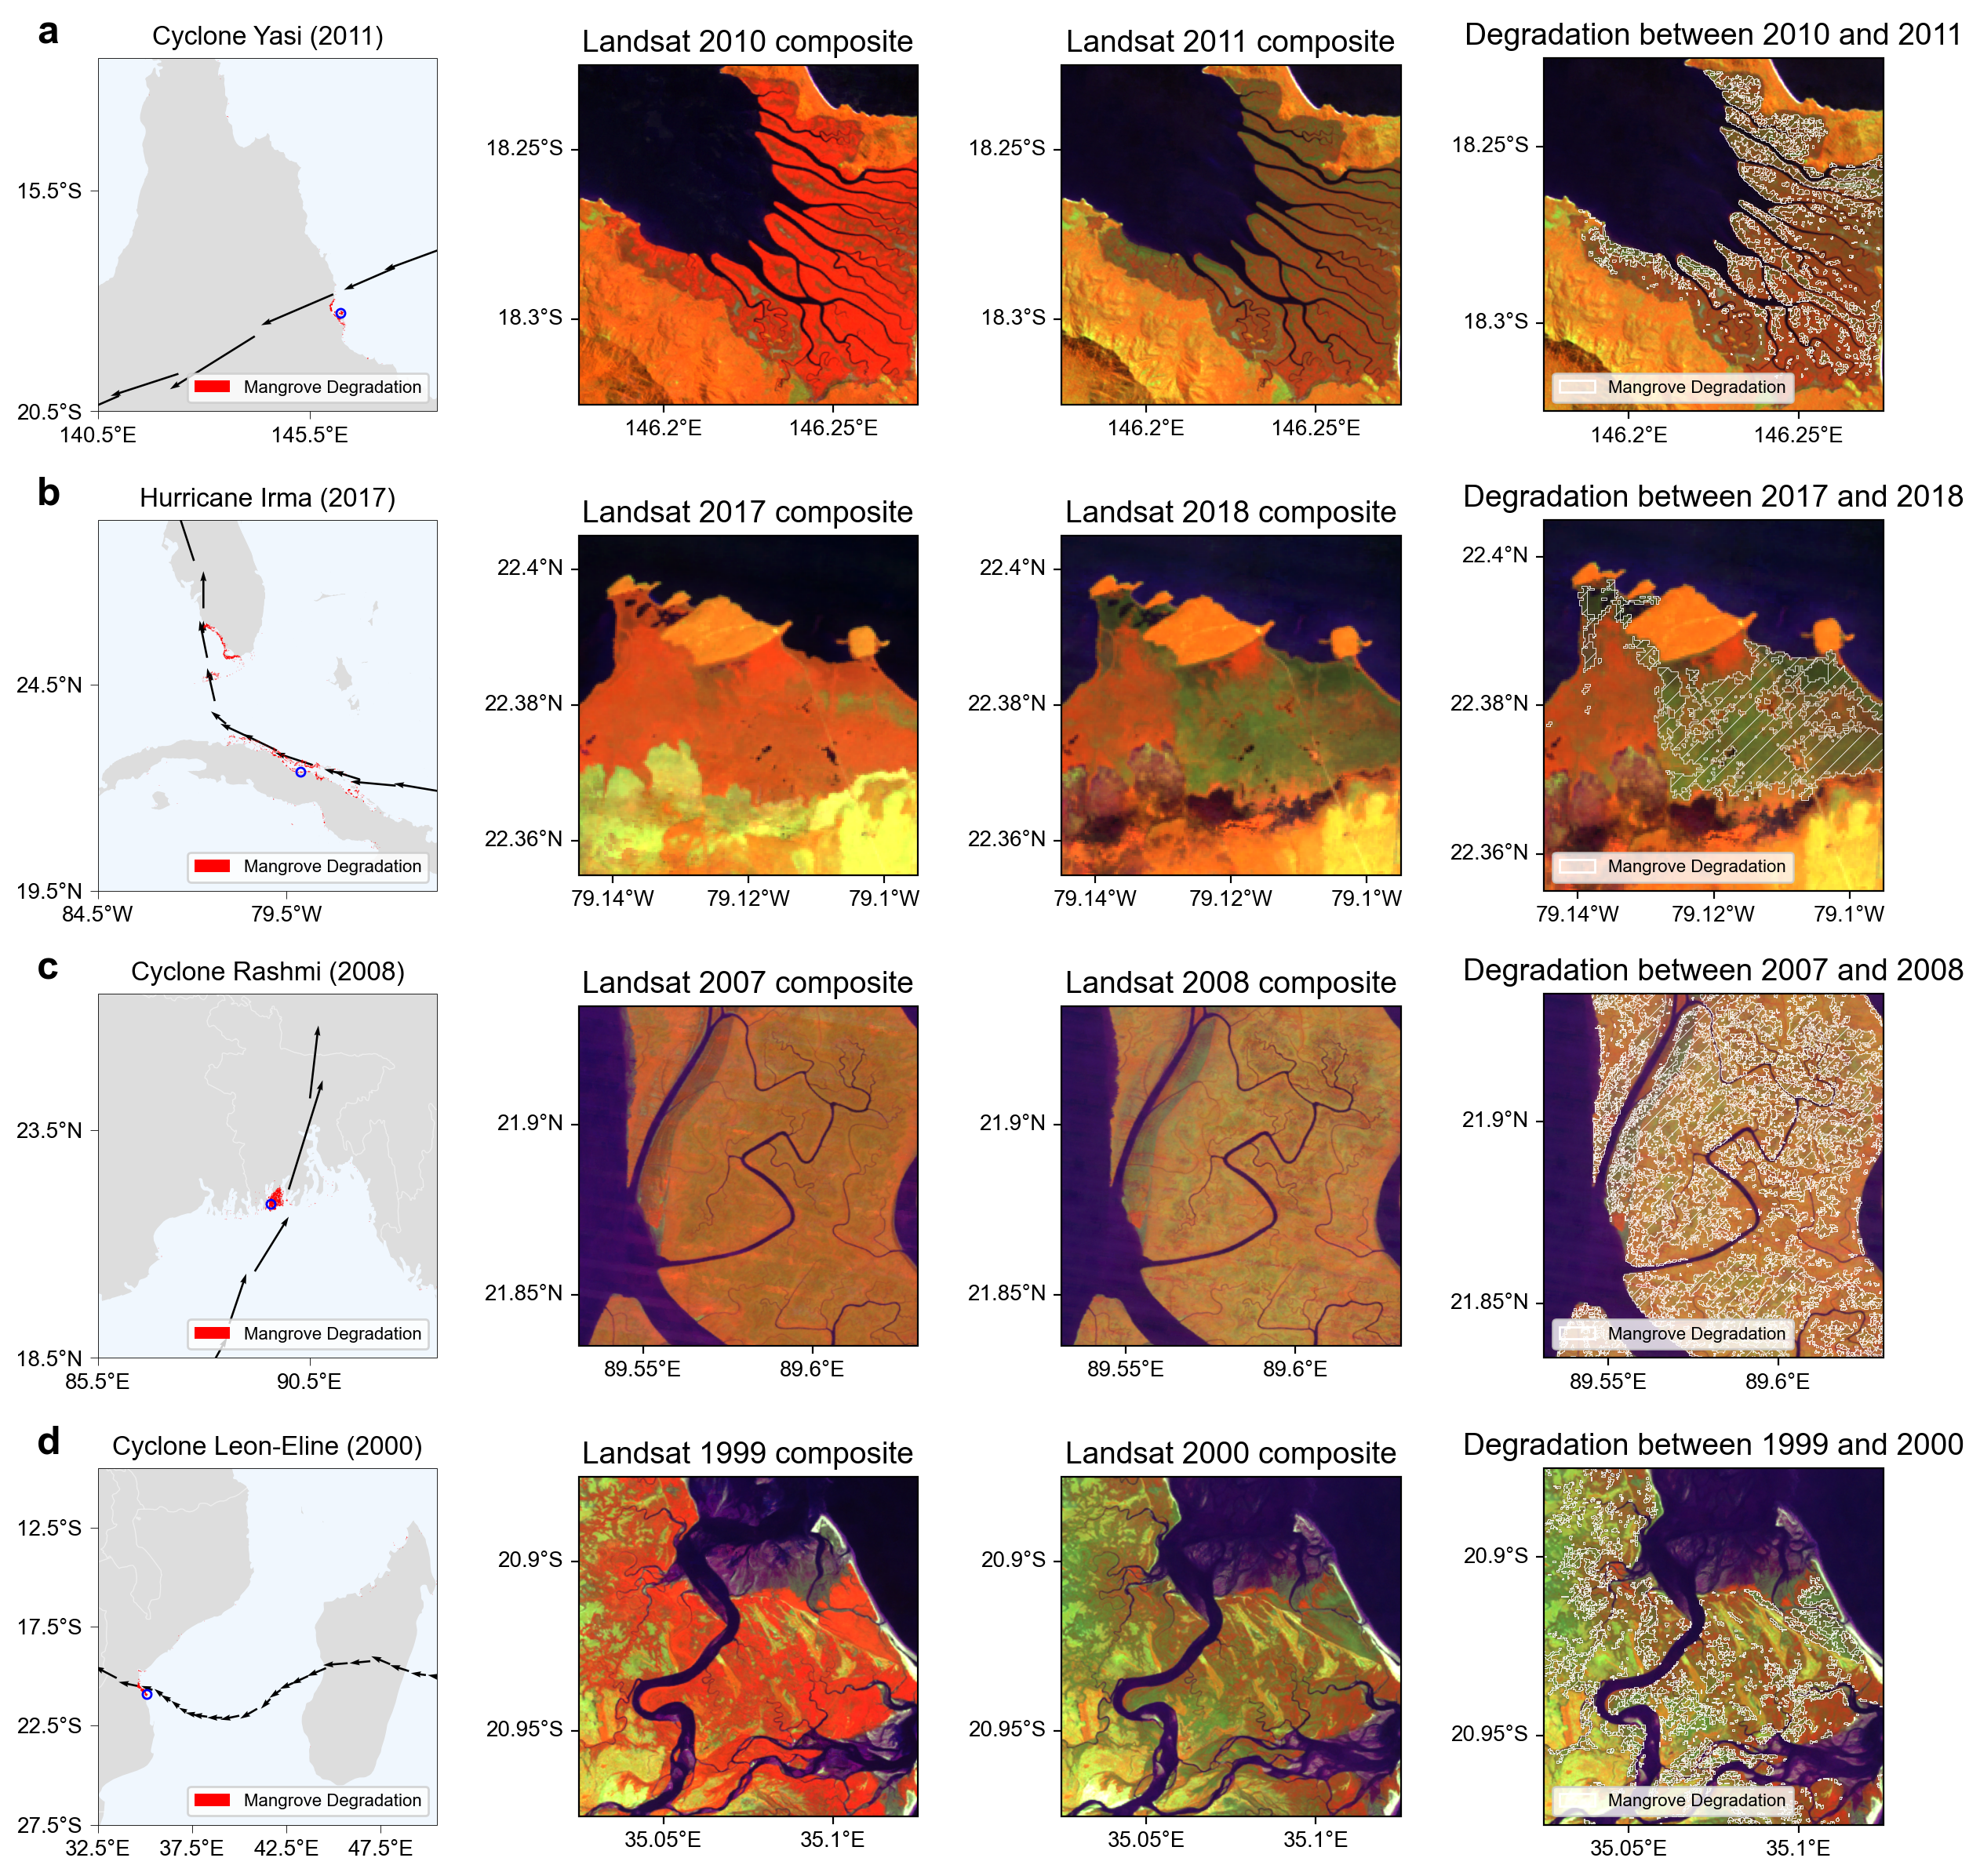

In [ ]:
fig = plt.figure(figsize=(12, 12),constrained_layout=True)
gs = GridSpec(nrows=4, ncols=4,figure=fig,wspace=0.1)

for row,cyclonename in enumerate(cyclone_info.keys()):
    ax = fig.add_subplot(gs[row,0],projection=ccrs.PlateCarree())
    storm = ibtracs.get_storm((cyclonename, cyclone_info[cyclonename][0])) # get storm by name and year
    cyclone_region = ZhenPlot.generating_extent(cyclone_info[cyclonename][1],xresolution=cyclone_info[cyclonename][2],yresolution=cyclone_info[cyclonename][2])
    degradation_layer = degradation_layers[row].cx[cyclone_region[0]:cyclone_region[1], cyclone_region[2]:cyclone_region[3]]
    degradation_layer = degradation_layer[degradation_layer['landcover']==1]
    plot_cyclone(ax,storm,cyclone_region)
    degradation_layer.plot(ax=ax, facecolor='none', edgecolor='red',linewidth=0.05, alpha=1, zorder=3)
    landsat_x, landsat_y = cyclone_info[cyclonename][3]
    ax.plot(landsat_x, landsat_y, 'o', markersize=4, markerfacecolor='none',  markeredgecolor='blue', transform=ccrs.PlateCarree(),zorder=3)
    legend_elements = [Patch(facecolor='red', label='Mangrove Degradation')]
    ax.legend(handles=legend_elements,ncol=1, loc='lower right', frameon=True, fontsize=8)
    ax.text(-0.18, 1.04, 'abcd'[row], transform=ax.transAxes, fontsize=18, fontweight='bold')
    ax.set_title(cyclone_info[cyclonename][6],fontsize=12)
    ZhenPlot.spine_setting(ax,0.3)

    if cyclonename == 'irma':
        interval=0.02
    else:
        interval=0.05
    landsat_region = ZhenPlot.generating_extent(cyclone_info[cyclonename][3],xresolution=cyclone_info[cyclonename][4],yresolution=cyclone_info[cyclonename][4])
    landsatyears = [cyclone_info[cyclonename][5],cyclone_info[cyclonename][5]+1,cyclone_info[cyclonename][5]+1]
    ax_234cols = [fig.add_subplot(gs[row,col],projection=ccrs.PlateCarree()) for col in range(1,4)]
    for j,ax_col in enumerate(ax_234cols):
        ZhenPlot.plot_landsat(ax_col,f'{landsatyears[j]}-01-01',f'{landsatyears[j]+1}-01-01',landsat_region,interval=interval)
        ax_col.set_title(f'Landsat {landsatyears[j]} composite',fontsize=14)
        if j == 2:
            degradation_layer.plot(ax=ax_col,
                facecolor='none',       # 透明填充
                edgecolor='white',      # 白色边框
                hatch='///',            # 设置斜线样式
                linewidth=0.3)
            mpl.rcParams['hatch.linewidth'] = 0.3 
            ax_col.set_extent(landsat_region)
            ax_col.set_title(f'Degradation between {landsatyears[j]-1} and {landsatyears[j]}',fontsize=14)
            legend_elements = [Patch(facecolor='none',edgecolor='white', label='Mangrove Degradation')]
            ax_col.legend(handles=legend_elements,ncol=1, loc='lower left', frameon=True, fontsize=8)
    # break
plt.savefig(r"Figures\CycloneExample.svg", dpi=500, format='svg', bbox_inches='tight')
plt.savefig(r"Figures\CycloneExample.png", dpi=500, format='png', bbox_inches='tight')
